# COSC2793 Assignment 2 - Wildfire Intensity Classification

Student: Praveen Kumar Saravanan (s4163448)  
Course: COSC2793  
Assessment: Machine Learning Classification and Model Comparison

This notebook implements the required workflow:
1. Task definition and dataset understanding
2. EDA and data handling
3. Model development (Decision Tree, SVM, Neural Network)
4. Hyperparameter analysis and model comparison
5. Final model selection and test prediction export

## Run Instructions

1. Ensure the two CSV files are in the same folder as this notebook:
   - `wildfire_cls_train_full.csv`
   - `wildfire_cls_test_features.csv`
2. Run all cells from top to bottom.
3. The prediction output will be saved as `{student_number}_predictions.csv` with one column named `fire_intensity`.

In [1]:
# Core imports
import warnings
from ast import literal_eval
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

RANDOM_STATE = 42
student_number = 's4163448'

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 100)

In [2]:
# Load data
train_path = 'wildfire_cls_train_full.csv'
test_path = 'wildfire_cls_test_features.csv'

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print('Train shape:', train_df.shape)
print('Test shape :', test_df.shape)
display(train_df.head(3))
display(test_df.head(3))

Train shape: (4340, 20)
Test shape : (1085, 19)


,latitude,longitude,acq_date,acq_time,year,month,season,daynight,region,country,fire_type,satellite,instrument,brightness_k,confidence,temp_max_c,wind_max_kmh,precip_mm,humidity_pct,fire_intensity
0,-22.1967,-61.5275,2024-08-12,1838,2024,NaN,Winter,D,South_America,Peru,Deforestation,Suomi-NPP,VIIRS,360.26,nominal,40.6,39.0,0.11,17.1,Extreme
1,64.2205,-53.4116,2024-07-11,424,2024,7.0,Summer,N,North_America,Canada,Forest,Suomi-NPP,VIIRS,326.20,high,38.9,NaN,0.06,13.2,Low
2,38.6810,9.5739,2024-06-18,546,2024,6.0,Summer,N,Mediterranean,Spain,Wildfire,AQUA,MODIS,343.36,high,36.9,30.1,0.19,35.2,High


,latitude,longitude,acq_date,acq_time,year,month,season,daynight,region,country,fire_type,satellite,instrument,brightness_k,confidence,temp_max_c,wind_max_kmh,precip_mm,humidity_pct
0,3.0704,-69.7330,2025-07-07,2156,2025,7,Summer,N,South_America,Peru,Savanna,NOAA-20,VIIRS,330.87,high,35.9,26.8,0.61,53.8
1,33.3533,-90.0083,2025-08-02,1638,2025,8,Summer,D,North_America,USA,Prescribed,NOAA-20,VIIRS,382.53,high,39.1,9.2,3.43,21.0
2,-28.7409,-9.3042,2025-09-22,2118,2025,9,Spring,N,Sub_Saharan_Africa,South Africa,Agriculture,TERRA,MODIS,316.81,high,37.9,14.2,0.62,18.1


## Task Definition

- **Task type**: Multiclass classification
- **Prediction target**: `fire_intensity`
- **Classes**: `Low`, `Moderate`, `High`, `Extreme` (mapped to 0, 1, 2, 3 for modelling consistency)
- **Metrics**: Accuracy and Macro F1

In [3]:
# Basic schema checks
print('Train columns:', list(train_df.columns))
print('Test columns :', list(test_df.columns))

missing_train = train_df.isna().sum().sort_values(ascending=False)
missing_test = test_df.isna().sum().sort_values(ascending=False)

print('\nTop missing values in train:')
display(missing_train[missing_train > 0].head(15))
print('\nTop missing values in test:')
display(missing_test[missing_test > 0].head(15))

Train columns: ['latitude', 'longitude', 'acq_date', 'acq_time', 'year', 'month', 'season', 'daynight', 'region', 'country', 'fire_type', 'satellite', 'instrument', 'brightness_k', 'confidence', 'temp_max_c', 'wind_max_kmh', 'precip_mm', 'humidity_pct', 'fire_intensity']
Test columns : ['latitude', 'longitude', 'acq_date', 'acq_time', 'year', 'month', 'season', 'daynight', 'region', 'country', 'fire_type', 'satellite', 'instrument', 'brightness_k', 'confidence', 'temp_max_c', 'wind_max_kmh', 'precip_mm', 'humidity_pct']

Top missing values in train:


month           416
brightness_k    327
wind_max_kmh    207
dtype: int64


Top missing values in test:


Series([], dtype: int64)

In [4]:
# Convert acq_date to useful numeric time features and drop raw date string
def add_date_features(df):
    out = df.copy()
    out['acq_date'] = pd.to_datetime(out['acq_date'], errors='coerce')
    out['acq_dayofyear'] = out['acq_date'].dt.dayofyear
    out['acq_weekofyear'] = out['acq_date'].dt.isocalendar().week.astype('float')
    out = out.drop(columns=['acq_date'])
    return out

train_df = add_date_features(train_df)
test_df = add_date_features(test_df)

print('Date feature engineering complete.')
display(train_df[['acq_dayofyear', 'acq_weekofyear']].head(3))

Date feature engineering complete.


,acq_dayofyear,acq_weekofyear
0,225,33.0
1,193,28.0
2,170,25.0


In [5]:
# Target encoding to integer classes required by many classifiers
target_col = 'fire_intensity'

label_to_int = {
    'Low': 0,
    'Moderate': 1,
    'High': 2,
    'Extreme': 3,
    'Extremd': 3
}
int_to_label = {0: 'Low', 1: 'Moderate', 2: 'High', 3: 'Extreme'}

y_raw = train_df[target_col].astype(str).str.strip()
y = y_raw.map(label_to_int)

if y.isna().any():
    unknown = sorted(y_raw[y.isna()].unique())
    raise ValueError(f'Unknown target labels encountered: {unknown}')

X = train_df.drop(columns=[target_col])
X_test = test_df.copy()

print('Encoded class distribution:')
display(y.value_counts().sort_index())

Encoded class distribution:


fire_intensity
0     698
1    1921
2    1340
3     381
Name: count, dtype: int64

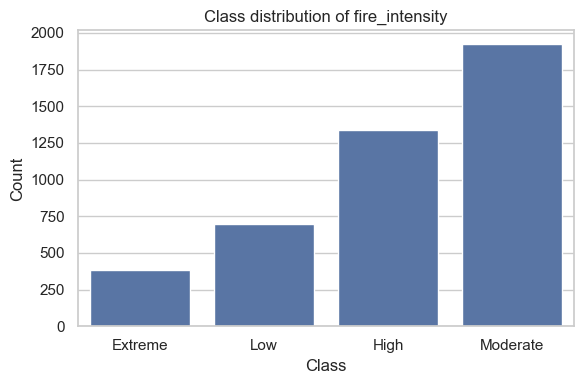

In [6]:
# EDA: class balance
plt.figure(figsize=(6, 4))
sns.countplot(x=y.map(int_to_label))
plt.title('Class distribution of fire_intensity')
plt.xlabel('Class')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

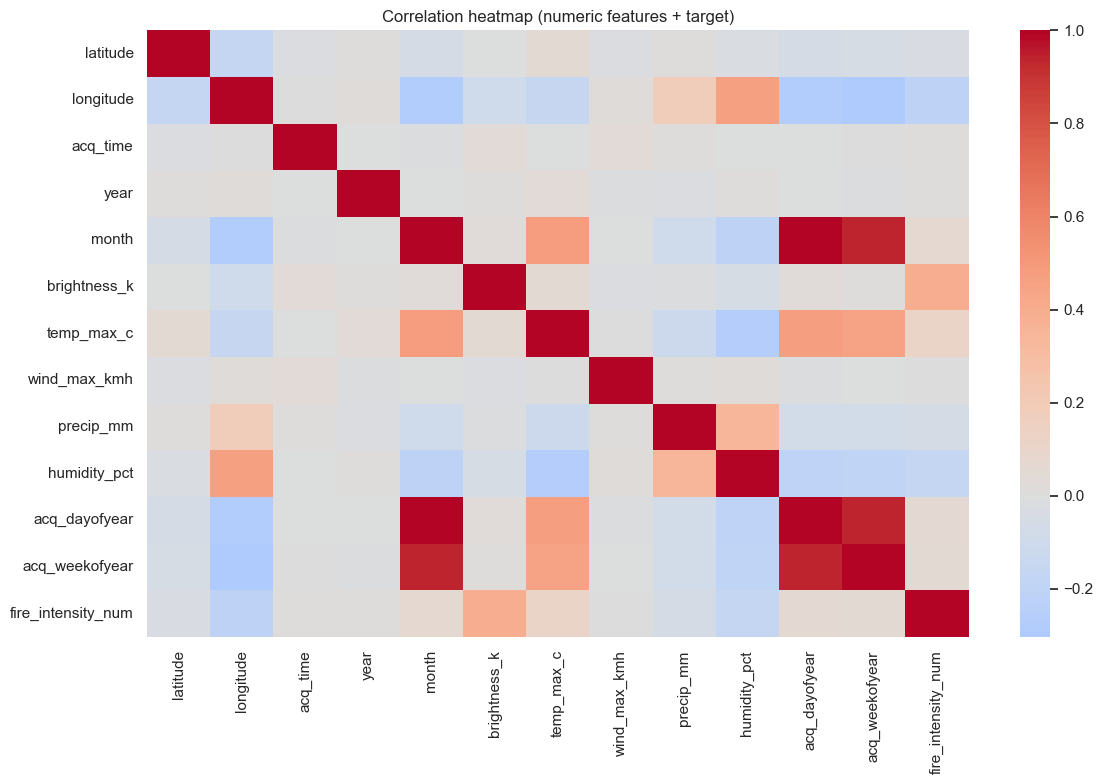

Top positive correlations with target:


brightness_k      0.388928
temp_max_c        0.118841
month             0.066834
acq_dayofyear     0.061463
acq_weekofyear    0.055667
year              0.013294
acq_time          0.008953
wind_max_kmh      0.002287
Name: fire_intensity_num, dtype: float64

Top negative correlations with target:


acq_weekofyear    0.055667
year              0.013294
acq_time          0.008953
wind_max_kmh      0.002287
latitude         -0.029989
precip_mm        -0.059050
humidity_pct     -0.163306
longitude        -0.215381
Name: fire_intensity_num, dtype: float64

In [7]:
# EDA: numeric relationships
numeric_cols_eda = X.select_dtypes(include=[np.number]).columns.tolist()
corr_df = pd.concat([X[numeric_cols_eda], y.rename('fire_intensity_num')], axis=1)
corr = corr_df.corr(numeric_only=True)

plt.figure(figsize=(12, 8))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title('Correlation heatmap (numeric features + target)')
plt.tight_layout()
plt.show()

target_corr = corr['fire_intensity_num'].drop('fire_intensity_num').sort_values(ascending=False)
print('Top positive correlations with target:')
display(target_corr.head(8))
print('Top negative correlations with target:')
display(target_corr.tail(8))

## Data Splitting and Preprocessing

- Hold-out validation: stratified 80/20 split
- Missing values: median (numeric), most frequent (categorical)
- Encoding: one-hot for categorical variables
- Scaling: standardization for numeric variables (important for SVM and MLP)

In [8]:
# Split data
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print('X_train:', X_train.shape, 'X_val:', X_val.shape)
print('y_train class counts:')
display(y_train.value_counts().sort_index())

X_train: (3472, 20) X_val: (868, 20)
y_train class counts:


fire_intensity
0     558
1    1537
2    1072
3     305
Name: count, dtype: int64

In [9]:
# Build preprocessing pipeline
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = [c for c in X.columns if c not in numeric_features]

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features),
    ]
)

print('Numeric features:', len(numeric_features))
print('Categorical features:', len(categorical_features))

Numeric features: 12
Categorical features: 8


In [10]:
# Shared evaluation helper
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def evaluate_pipeline(model, model_name):
    pipe = Pipeline([
        ('preprocess', preprocessor),
        ('model', model)
    ])

    pipe.fit(X_train, y_train)
    y_train_pred = pipe.predict(X_train)
    y_val_pred = pipe.predict(X_val)

    train_acc = accuracy_score(y_train, y_train_pred)
    val_acc = accuracy_score(y_val, y_val_pred)
    train_f1 = f1_score(y_train, y_train_pred, average='macro')
    val_f1 = f1_score(y_val, y_val_pred, average='macro')

    cv_scores = cross_validate(
        pipe, X_train, y_train, cv=cv,
        scoring={'acc': 'accuracy', 'f1_macro': 'f1_macro'},
        n_jobs=-1
    )

    return {
        'Model': model_name,
        'Train_Acc': train_acc,
        'Val_Acc': val_acc,
        'Train_F1': train_f1,
        'Val_F1': val_f1,
        'CV_Acc': cv_scores['test_acc'].mean(),
        'CV_F1': cv_scores['test_f1_macro'].mean(),
        'Pipeline': pipe
    }

## Model 1: Decision Tree

Hyperparameters explored:
- `max_depth` (required complexity control)
- `min_samples_leaf` (additional COSC2793 hyperparameter)

In [ ]:
# Decision Tree experiments
dt_rows = []
depth_grid = [3, 5, 8, 12, 16, None]
leaf_grid = [1, 3, 5, 10]

for depth in depth_grid:
    for leaf in leaf_grid:
        dt = DecisionTreeClassifier(
            max_depth=depth,
            min_samples_leaf=leaf,
            random_state=RANDOM_STATE
        )
        row = evaluate_pipeline(dt, 'DecisionTree')
        row['max_depth'] = -1 if depth is None else depth
        row['min_samples_leaf'] = leaf
        dt_rows.append(row)

dt_df = pd.DataFrame(dt_rows).sort_values('Val_F1', ascending=False).reset_index(drop=True)
display(dt_df[['max_depth', 'min_samples_leaf', 'Train_Acc', 'Val_Acc', 'Train_F1', 'Val_F1', 'CV_Acc', 'CV_F1']].head(10))

In [ ]:
# Decision Tree performance curve
plot_dt = dt_df.groupby('max_depth', as_index=False)['Val_F1'].max().sort_values('max_depth')
plt.figure(figsize=(7, 4))
sns.lineplot(data=plot_dt, x='max_depth', y='Val_F1', marker='o')
plt.title('Decision Tree: Validation Macro F1 vs max_depth')
plt.xlabel('max_depth (-1 means None)')
plt.ylabel('Validation Macro F1')
plt.tight_layout()
plt.show()

In [ ]:
# Visualize best Decision Tree structure (truncated depth for readability)
best_dt_depth = None if int(dt_df.loc[0, 'max_depth']) == -1 else int(dt_df.loc[0, 'max_depth'])
best_dt_leaf = int(dt_df.loc[0, 'min_samples_leaf'])

best_dt = DecisionTreeClassifier(
    max_depth=best_dt_depth,
    min_samples_leaf=best_dt_leaf,
    random_state=RANDOM_STATE
)
best_dt_pipe = Pipeline([('preprocess', preprocessor), ('model', best_dt)])
best_dt_pipe.fit(X_train, y_train)

feature_names = best_dt_pipe.named_steps['preprocess'].get_feature_names_out()
tree_model = best_dt_pipe.named_steps['model']

plt.figure(figsize=(22, 10))
plot_tree(
    tree_model,
    feature_names=feature_names,
    class_names=['0', '1', '2', '3'],
    filled=True,
    max_depth=3,
    fontsize=8
)
plt.title('Best Decision Tree (first 4 levels shown)')
plt.tight_layout()
plt.show()

## Model 2: SVM

Hyperparameters explored:
- Kernel: `linear` vs `rbf`
- `C` (required regularization)
- `gamma` for RBF (additional COSC2793 hyperparameter)

In [ ]:
# SVM experiments
svm_rows = []
c_grid = [0.1, 1, 10, 50]
gamma_grid = ['scale', 0.01, 0.1, 1.0]

# Linear kernel: vary C
for c in c_grid:
    svm_linear = SVC(kernel='linear', C=c, random_state=RANDOM_STATE)
    row = evaluate_pipeline(svm_linear, 'SVM_linear')
    row['kernel'] = 'linear'
    row['C'] = c
    row['gamma'] = np.nan
    svm_rows.append(row)

# RBF kernel: vary C and gamma
for c in c_grid:
    for g in gamma_grid:
        svm_rbf = SVC(kernel='rbf', C=c, gamma=g, random_state=RANDOM_STATE)
        row = evaluate_pipeline(svm_rbf, 'SVM_rbf')
        row['kernel'] = 'rbf'
        row['C'] = c
        row['gamma'] = g
        svm_rows.append(row)

svm_df = pd.DataFrame(svm_rows).sort_values('Val_F1', ascending=False).reset_index(drop=True)
display(svm_df[['kernel', 'C', 'gamma', 'Train_Acc', 'Val_Acc', 'Train_F1', 'Val_F1', 'CV_Acc', 'CV_F1']].head(12))

In [ ]:
# SVM performance visualizations
plt.figure(figsize=(7, 4))
sns.lineplot(data=svm_df[svm_df['kernel'] == 'linear'].sort_values('C'), x='C', y='Val_F1', marker='o')
plt.xscale('log')
plt.title('SVM Linear: Validation Macro F1 vs C')
plt.xlabel('C (log scale)')
plt.ylabel('Validation Macro F1')
plt.tight_layout()
plt.show()

rbf_plot = svm_df[svm_df['kernel'] == 'rbf'].copy()
rbf_plot['gamma_str'] = rbf_plot['gamma'].astype(str)
heat = rbf_plot.pivot_table(index='C', columns='gamma_str', values='Val_F1', aggfunc='max')

plt.figure(figsize=(8, 5))
sns.heatmap(heat, annot=True, fmt='.3f', cmap='YlGnBu')
plt.title('SVM RBF: Validation Macro F1 (C x gamma)')
plt.tight_layout()
plt.show()

## Model 3: Neural Network (MLP)

Hyperparameters explored:
- `learning_rate_init` (required)
- `hidden_layer_sizes` (additional COSC2793 hyperparameter)

For each setting we record Accuracy, Macro F1, and training loss curves.

In [ ]:
# Neural network experiments
nn_rows = []
loss_curves = {}
lr_grid = [0.0005, 0.001, 0.005, 0.01]
hidden_grid = [(32,), (64,), (64, 32)]

for lr in lr_grid:
    for hidden in hidden_grid:
        mlp = MLPClassifier(
            hidden_layer_sizes=hidden,
            learning_rate_init=lr,
            max_iter=200,
            early_stopping=True,
            validation_fraction=0.1,
            n_iter_no_change=15,
            random_state=RANDOM_STATE
        )

        pipe = Pipeline([('preprocess', preprocessor), ('model', mlp)])
        pipe.fit(X_train, y_train)

        y_train_pred = pipe.predict(X_train)
        y_val_pred = pipe.predict(X_val)

        row = {
            'Model': 'MLP',
            'learning_rate_init': lr,
            'hidden_layer_sizes': str(hidden),
            'Train_Acc': accuracy_score(y_train, y_train_pred),
            'Val_Acc': accuracy_score(y_val, y_val_pred),
            'Train_F1': f1_score(y_train, y_train_pred, average='macro'),
            'Val_F1': f1_score(y_val, y_val_pred, average='macro')
        }

        cv_scores = cross_validate(
            Pipeline([('preprocess', preprocessor), ('model', mlp)]),
            X_train, y_train, cv=cv,
            scoring={'acc': 'accuracy', 'f1_macro': 'f1_macro'},
            n_jobs=-1
        )
        row['CV_Acc'] = cv_scores['test_acc'].mean()
        row['CV_F1'] = cv_scores['test_f1_macro'].mean()

        nn_rows.append(row)
        key = f'lr={lr}, hidden={hidden}'
        loss_curves[key] = pipe.named_steps['model'].loss_curve_

nn_df = pd.DataFrame(nn_rows).sort_values('Val_F1', ascending=False).reset_index(drop=True)
display(nn_df.head(12))

In [ ]:
# MLP performance curves
plt.figure(figsize=(7, 4))
lr_perf = nn_df.groupby('learning_rate_init', as_index=False)['Val_F1'].max().sort_values('learning_rate_init')
sns.lineplot(data=lr_perf, x='learning_rate_init', y='Val_F1', marker='o')
plt.xscale('log')
plt.title('MLP: Validation Macro F1 vs learning_rate_init')
plt.xlabel('learning_rate_init (log scale)')
plt.ylabel('Validation Macro F1')
plt.tight_layout()
plt.show()

# Plot a few loss curves for learning-rate comparison
plt.figure(figsize=(9, 5))
shown = 0
for key, curve in loss_curves.items():
    if 'hidden=(64,)' in key and shown < 4:
        plt.plot(curve, label=key)
        shown += 1

plt.title('MLP Training Loss Curves (hidden=(64,))')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

## Model Comparison and Final Selection

Primary ranking metric: **Validation Macro F1**  
Secondary checks: Validation Accuracy and CV scores

In [ ]:
# Consolidate best row from each model family
best_dt_row = dt_df.iloc[0].copy()
best_svm_row = svm_df.iloc[0].copy()
best_nn_row = nn_df.iloc[0].copy()

comparison = pd.DataFrame([
    {
        'Model_Family': 'DecisionTree',
        'Val_Acc': best_dt_row['Val_Acc'],
        'Val_F1': best_dt_row['Val_F1'],
        'CV_Acc': best_dt_row['CV_Acc'],
        'CV_F1': best_dt_row['CV_F1'],
        'Details': f"max_depth={best_dt_row['max_depth']}, min_samples_leaf={best_dt_row['min_samples_leaf']}"
    },
    {
        'Model_Family': 'SVM',
        'Val_Acc': best_svm_row['Val_Acc'],
        'Val_F1': best_svm_row['Val_F1'],
        'CV_Acc': best_svm_row['CV_Acc'],
        'CV_F1': best_svm_row['CV_F1'],
        'Details': f"kernel={best_svm_row['kernel']}, C={best_svm_row['C']}, gamma={best_svm_row['gamma']}"
    },
    {
        'Model_Family': 'NeuralNetwork',
        'Val_Acc': best_nn_row['Val_Acc'],
        'Val_F1': best_nn_row['Val_F1'],
        'CV_Acc': best_nn_row['CV_Acc'],
        'CV_F1': best_nn_row['CV_F1'],
        'Details': f"learning_rate_init={best_nn_row['learning_rate_init']}, hidden_layer_sizes={best_nn_row['hidden_layer_sizes']}"
    }
]).sort_values(['Val_F1', 'Val_Acc'], ascending=False).reset_index(drop=True)

display(comparison)

plt.figure(figsize=(7, 4))
sns.barplot(data=comparison, x='Model_Family', y='Val_F1')
plt.title('Validation Macro F1 Comparison')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

selected_family = comparison.loc[0, 'Model_Family']
print('Selected model family:', selected_family)
print('Best settings:', comparison.loc[0, 'Details'])

In [ ]:
# Build final selected model using best hyperparameters and evaluate confusion matrix on validation
if selected_family == 'DecisionTree':
    depth_val = int(best_dt_row['max_depth'])
    final_depth = None if depth_val == -1 else depth_val
    final_model = DecisionTreeClassifier(
        max_depth=final_depth,
        min_samples_leaf=int(best_dt_row['min_samples_leaf']),
        random_state=RANDOM_STATE
    )
elif selected_family == 'SVM':
    final_model = SVC(
        kernel=best_svm_row['kernel'],
        C=float(best_svm_row['C']),
        gamma=best_svm_row['gamma'] if best_svm_row['kernel'] == 'rbf' else 'scale',
        random_state=RANDOM_STATE
    )
else:
    hidden = literal_eval(best_nn_row['hidden_layer_sizes'])
    final_model = MLPClassifier(
        hidden_layer_sizes=hidden,
        learning_rate_init=float(best_nn_row['learning_rate_init']),
        max_iter=200,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=15,
        random_state=RANDOM_STATE
    )

final_pipe = Pipeline([('preprocess', preprocessor), ('model', final_model)])
final_pipe.fit(X_train, y_train)
y_val_pred = final_pipe.predict(X_val)

print('Validation Accuracy:', round(accuracy_score(y_val, y_val_pred), 4))
print('Validation Macro F1:', round(f1_score(y_val, y_val_pred, average='macro'), 4))
print('\nClassification report:')
print(classification_report(y_val, y_val_pred, digits=4))

cm = confusion_matrix(y_val, y_val_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Validation Confusion Matrix')
plt.xlabel('Predicted class')
plt.ylabel('True class')
plt.tight_layout()
plt.show()

In [ ]:
# Refit selected model on full training data and predict test data
final_pipe.fit(X, y)
test_pred_int = final_pipe.predict(X_test)
test_pred_label = pd.Series(test_pred_int).map(int_to_label)

out_file = f'{student_number}_predictions.csv'
pred_df = pd.DataFrame({'fire_intensity': test_pred_label})
pred_df.to_csv(out_file, index=False)

print('Saved prediction file:', out_file)
display(pred_df.head())
print('Prediction shape:', pred_df.shape)
assert pred_df.shape[0] == X_test.shape[0]
assert list(pred_df.columns) == ['fire_intensity']

## Discussion Prompts for Report Writing

Use your observed results to complete the written report:
- How missing values were handled and why
- How each hyperparameter changed train vs validation behaviour
- Where underfitting or overfitting appeared
- Why the final selected model is preferred beyond raw performance
- Ethical and professional considerations (resource allocation bias, false negatives vs false positives, deployment monitoring)

Also include your GenAI usage declaration according to course policy.